# chi square test in python


# categorical data

In [1]:
import seaborn as sns
data=sns.load_dataset('tips')

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [3]:
data.isnull()    #to check null value

,total_bill,tip,sex,smoker,day,time,size
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
239,False,False,False,False,False,False,False
240,False,False,False,False,False,False,False
241,False,False,False,False,False,False,False
242,False,False,False,False,False,False,False


In [4]:
data.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [5]:
data.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [6]:
data[['sex','smoker']]

,sex,smoker
0,Female,No
1,Male,No
2,Male,No
3,Male,No
4,Female,No
...,...,...
239,Male,No
240,Female,Yes
241,Male,Yes
242,Male,No


In [7]:
data['sex'].value_counts()

sex
Male      157
Female     87
Name: count, dtype: int64

In [8]:
data['smoker'].value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

In [9]:
import pandas as pd

In [10]:
#pd.crosstab(...): Function that counts how often each combination of the two appears.
pd.crosstab(data['sex'],data['smoker'])

smoker,Yes,No
sex,,
Male,60,97
Female,33,54


In [11]:
data.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [12]:
pd.crosstab(data['sex'],data['time'])

time,Lunch,Dinner
sex,,
Male,33,124
Female,35,52


# The Chi-Square Test for Independence checks if two categorical variables are independent or related.



In [19]:
data_table=pd.crosstab(data['sex'],data['time'])

In [20]:
data_table

time,Lunch,Dinner
sex,,
Male,33,124
Female,35,52


In [21]:
data_array=data_table.values

In [22]:
data_array

array([[ 33, 124],
       [ 35,  52]])

In [18]:
print(f"this is my observed value {data_array}")

this is my observed value [[ 33 124]
 [ 35  52]]


# scipy.stats helps you analyze your data statistically — it’s like a toolbox for all things related to statistics, probability, and hypothesis testing.

In [26]:
import scipy.stats as stats

In [27]:
stats.chi2_contingency(data_array)  #used to perform the Chi-Square Test of Independence.

Chi2ContingencyResult(statistic=np.float64(9.343808982970623), pvalue=np.float64(0.002237400118075248), dof=1, expected_freq=array([[ 43.75409836, 113.24590164],
       [ 24.24590164,  62.75409836]]))

In [28]:
stats_test,p,dof,Expected_values = stats.chi2_contingency(data_array) 

In [29]:
stats_test,p,dof,Expected_values

(np.float64(9.343808982970623),
 np.float64(0.002237400118075248),
 1,
 array([[ 43.75409836, 113.24590164],
        [ 24.24590164,  62.75409836]]))

In [30]:
Expected_values

array([[ 43.75409836, 113.24590164],
       [ 24.24590164,  62.75409836]])

In [32]:
print(f"here is my expected vale \n {Expected_values}")

here is my expected vale 
 [[ 43.75409836 113.24590164]
 [ 24.24590164  62.75409836]]


In [34]:
#how to write chi square formula using python?
from scipy.stats import chi


# The zip() function in Python is used to pair elements from two or more iterables (like lists, arrays, etc.) element by element.

In [40]:
for o,e in zip (data_array,Expected_values ):
    print(o,e)

[ 33 124] [ 43.75409836 113.24590164]
[35 52] [24.24590164 62.75409836]


In [41]:
for i in zip (data_array,Expected_values):
    print(i)

(array([ 33, 124]), array([ 43.75409836, 113.24590164]))
(array([35, 52]), array([24.24590164, 62.75409836]))


In [42]:
for o,e in zip (data_array,Expected_values):
    print((o-e)**2/e)

[2.6431954  1.02123459]
[4.76990434 1.84291759]


In [46]:
sum([(o-e)**2/e for o,e in zip (data_array,Expected_values )])

array([7.41309974, 2.86415217])

In [47]:
chisquare_test=sum([(o-e)**2/e for o,e in zip (data_array,Expected_values )])

In [49]:
sum(chisquare_test)

np.float64(10.277251918677742)

In [67]:
alpha=0.05

In [68]:
dof=1

In [69]:
from scipy.stats import chi2
critical_value=chi2.ppf(1-alpha,df=dof)

In [71]:
critical_value

np.float64(3.841458820694124)

In [73]:
if sum(chisquare_test)>=critical_value:
    print("reject H0, there is a relationship between 2 categorical variables")
else:
    print("retain H0,there is no relationship between 2 categorical variables")

reject H0, there is a relationship between 2 categorical variables


# ANOVA (Analysis of Variance) is a statistical test used to determine whether there are significant differences between the means of three or more independent groups.

1. one way anova
2. two way anova
3. n-way anova

In [74]:
import numpy as np
from scipy.stats import f_oneway


In [75]:
# Scores from 3 colleges
college_A = [85, 88, 90, 92, 87]
college_B = [78, 76, 74, 80, 79]
college_C = [90, 94, 91, 93, 89]


In [76]:
f_stat, p_value = f_oneway(college_A, college_B, college_C)

In [77]:
print("F-statistic:", f_stat)
print("P-value:", p_value)


F-statistic: 46.83908045977002
P-value: 2.1437591720339235e-06


In [78]:
alpha = 0.05

In [79]:

if p_value < alpha:
    print("Reject H0: There is a significant difference between at least one pair of colleges.")
else:
    print("Retain H0: No significant difference between the group means.")


Reject H0: There is a significant difference between at least one pair of colleges.


C:\Users\monika Bhati\AppData\Local\Temp\ipykernel_29780\2678642529.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


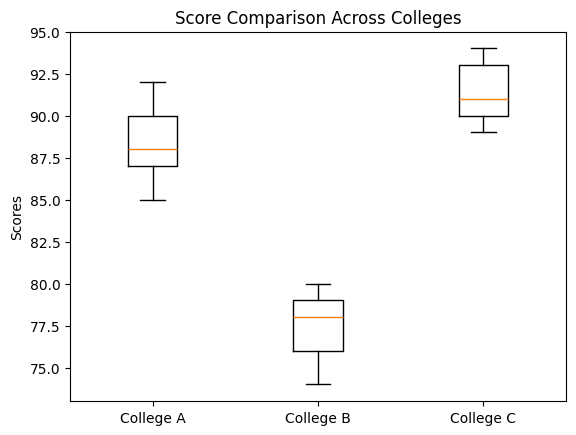

In [80]:
import matplotlib.pyplot as plt

data = [college_A, college_B, college_C]
labels = ['College A', 'College B', 'College C']

plt.boxplot(data, labels=labels)
plt.title("Score Comparison Across Colleges")
plt.ylabel("Scores")
plt.show()
